<a href="https://colab.research.google.com/github/animatedhawk18/TFM-normalizacion-medicamentos/blob/main/tfm_modelo_empaques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================
# 1. LIBRERÍAS
# ================================

import pandas as pd
import re
import unicodedata
from google.colab import files


# ================================
# 2. CARGAR ARCHIVO
# ================================

print("Sube tu archivo Excel:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)


# ================================
# 3. EXPLORACIÓN INICIAL
# ================================

print("Dimensiones del DataFrame:", df.shape)

display(df.head())

print("\nValores nulos por columna:")
display(df.isnull().sum())

print("\nNúmero total de valores nulos:", df.isnull().sum().sum())


Sube tu archivo Excel:


Saving Ambulatorios para IA.xlsx to Ambulatorios para IA (1).xlsx
Dimensiones del DataFrame: (35589, 15)


,expediente,CUM,Concentración DCI,Principio activo,Principio activo ATC,Denominación marcaria,Cantidad,Unidad de medida,Forma farmacéutica,Vía de administración,Diferenciador por fabricante,Unidad de empaque,cantidadcum,unidadreferencia,CÓDIGO ATC
0,20064694,20064694-01,ABACAVIR 300mg,ABACAVIR SULFATO EQUIVALENTE A ABACAVIR,ABACAVIR,ABACAR®,300.0,mg,TABLETA RECUBIERTA,ORAL,HETERO LABS LIMITED,FRASCO DE HDPE POR 60 TABLETAS CON TAPA PLASTI...,60.0,CADA TABLETA,J05AF06
1,20065664,20065664-02,ABACAVIR SULFATO 20mg/1ml,ABACAVIR SULFAT0 2.34 G EQUIVALENTE A ABACAVIR,ABACAVIR,ABACAR® SOLUCION ORAL,2.0,g,SOLUCION ORAL,ORAL,HETERO LABS LIMITED,CAJA CON FRASCO DE POLIETILENO DE ALTA DENSIDA...,1.0,100 ML DE SOLUCION ORAL,J05AF06
2,20041743,20041743-01,ABATACEPT 125mg/1ml,ABATACEPT,ABATACEPT,ORENCIA® SOLUCION INYECTABLE PARA ADMINISTRACI...,125.0,mg,SOLUCION INYECTABLE,SUBCUTANEA,BRISTOL MYERS SQUIBB DE COLOMBIA S.A,CAJA CON 4 JERINGAS PRELLENADAS DE DOSIS UNICA,4.0,JERINGA PRELLENADA,L04AA24
3,20148436,20148436-03,ABIRATERONA ACETATO 250mg,ABIRATERONA ACETATO,ABIRATERONA,ABIRAND ® 250 MG TABLETAS,250.0,mg,TABLETA,ORAL,MSN LABORATORIES PRIVATE LIMITED,FRASCO EN POLIETILENO DE ALTA DENSIDAD CON TAP...,120.0,TABLETAS,L02BX03
4,20178599,20178599-01,ABIRATERONA ACETATO 500mg,ACETATO DE ABIRATERONA,ABIRATERONA,ABIRAPROST®,500.0,mg,TABLETA,ORAL,LABORATORIOS LA SANTE S.A.,CAJA PLEGADIZA CON UN FRASCO DE POLIETILENO BL...,60.0,TABLETA,L02BX03



Valores nulos por columna:


,0
expediente,0
CUM,0
Concentración DCI,0
Principio activo,0
Principio activo ATC,0
Denominación marcaria,0
Cantidad,0
Unidad de medida,0
Forma farmacéutica,0
Vía de administración,0



Número total de valores nulos: 216


#PASO 2 — Pipeline de normalización de texto

##2.1 Definir diccionarios de normalización

Objetivo:
 Estandarizar la información textual para reducir variabilidad semántica
 y facilitar la extracción estructurada posterior.

 Problema:
 Los textos de empaques presentan:
 - Inconsistencias en espacios
 - Uso de abreviaturas
 - Mezcla de números y texto
 - Variabilidad en escritura de unidades

 Solución:
 Se construye un pipeline de normalización que:
 - Unifica formato (mayúsculas, sin tildes)
 - Corrige separadores y espacios
 - Convierte números en texto a formato numérico
 - Estandariza términos clave (envases, operadores)

 Esto permite que las reglas posteriores sean más simples y robustas.

En este punto se resalta la función normalizar_separadores. Esta función es clave para evitar regex complejos.
 En lugar de manejar múltiples variaciones en cada patrón, se normalizan previamente los separadores y espacios,  reduciendo la complejidad del sistema.



In [ ]:
# ================================
# CONFIGURACIÓN GLOBAL
# ================================

import re
import unicodedata
import pandas as pd

ABREVIATURAS = {
    "C/U.": "CADA_UNO",
    "C/U": "CADA_UNO",
    "CADA UNO": "CADA_UNO"
}

NUMEROS_TEXTO = {
    "UN": 1, "UNO": 1,
    "DOS": 2, "TRES": 3, "CUATRO": 4, "CINCO": 5,
    "SEIS": 6, "SIETE": 7, "OCHO": 8, "NUEVE": 9,
    "DIEZ": 10, "VEINTE": 20, "TREINTA": 30,
    "CUARENTA": 40, "CINCUENTA": 50
}

# Regex precompilados
REGEX = {
    "x": re.compile(r"\sX\s"),
    "espacios": re.compile(r"\s+"),
    "num_letra": re.compile(r'(\d)([A-Z])'),
    "letra_num": re.compile(r'([A-Z])(\d)'),
}


# ================================
# FUNCIONES AUXILIARES
# ================================

def limpiar_tildes(texto):
    texto = unicodedata.normalize("NFKD", texto)
    return texto.encode("ASCII", "ignore").decode("utf-8")


def normalizar_separadores(texto):
    # Unificar separadores a espacio
    texto = re.sub(r"[-_/]", " ", texto)

    # Separar palabras pegadas críticas
    texto = re.sub(r'(FRASCOS?)(VIAL)', r'\1 \2', texto)
    texto = re.sub(r'(FRASCOS?)(AMPOLLAS?)', r'\1 \2', texto)

    # Normalizar espacios
    texto = re.sub(r'\s+', ' ', texto)

    return texto.strip()


def separar_numeros(texto):
    texto = REGEX["num_letra"].sub(r'\1 \2', texto)
    texto = REGEX["letra_num"].sub(r'\1 \2', texto)
    return texto


def reemplazar_abreviaturas(texto):
    for abrev, completo in ABREVIATURAS.items():
        texto = texto.replace(abrev, completo)
    return texto


def convertir_numeros(texto):
    for palabra, numero in NUMEROS_TEXTO.items():
        texto = re.sub(rf"\b{palabra}\b", str(numero), texto)
    return texto


def normalizar_operadores(texto):
    return REGEX["x"].sub(" POR ", texto)


def limpiar_espacios(texto):
    return REGEX["espacios"].sub(" ", texto).strip()


# ================================
# NORMALIZACIÓN DE ENVASES
# ================================

def normalizar_envases_complejos(texto):

    patrones_vial = [
        r'\bFRASCOS?\s+VIAL(ES)?\b',
        r'\bFRASCOS?\s+DE\s+VIAL(ES)?\b',
        r'\bFRASCOS?\s+VIDRIO\s+VIAL(ES)?\b',
        r'\bFRASCOS?\s+DE\s+SOLUCION.*?VIAL\b'
    ]

    patrones_ampolla = [
        r'\bFRASCOS?\s+AMPOLLAS?\b',
        r'\bFRASCOS?\s+DE\s+VIDRIO\s+AMPOLLA\b'
    ]

    for patron in patrones_vial:
        texto = re.sub(patron, 'VIAL', texto)

    for patron in patrones_ampolla:
        texto = re.sub(patron, 'AMPOLLA', texto)

    return texto


# ================================
# PIPELINE PRINCIPAL
# ================================

def normalizar_texto_pipeline(texto):

    if pd.isna(texto):
        return ""

    # 1. Mayúsculas
    texto = texto.upper()

    # 2. Quitar tildes
    texto = limpiar_tildes(texto)

    # 🔥 3. NORMALIZAR SEPARADORES (CLAVE PARA LOS ESPACIOS)
    texto = normalizar_separadores(texto)

    # 4. Separar números pegados
    texto = separar_numeros(texto)

    # 5. Abreviaturas
    texto = reemplazar_abreviaturas(texto)

    # 6. Números en texto → número
    texto = convertir_numeros(texto)

    # 7. Normalizar X → POR
    texto = normalizar_operadores(texto)

    # 8. Normalizar envases
    texto = normalizar_envases_complejos(texto)

    # 9. Limpieza final de espacios
    texto = limpiar_espacios(texto)

    return texto


# ================================
# LIMPIEZA PREVIA Y APLICACIÓN
# ================================

df['Unidad de empaque'] = df['Unidad de empaque'].str.replace(
    r"SIN\s*DATO",
    "",
    regex=True
)

df['texto_norm'] = df['Unidad de empaque'].apply(normalizar_texto_pipeline)

#3. Análisis exploratorio

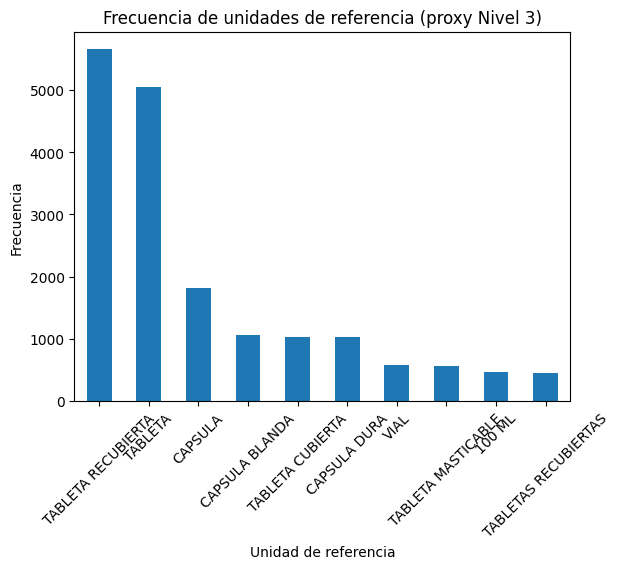

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
df["unidadreferencia"].value_counts().head(10).plot(kind="bar")
plt.title("Frecuencia de unidades de referencia (proxy Nivel 3)")
plt.xlabel("Unidad de referencia")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

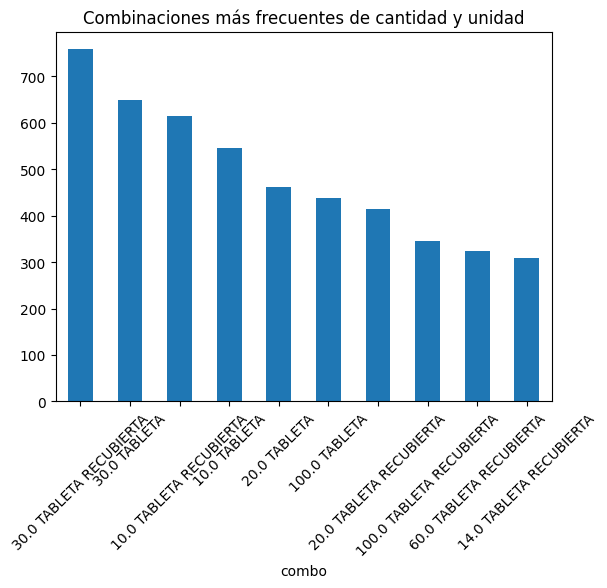

In [ ]:
df["combo"] = df["cantidadcum"].astype(str) + " " + df["unidadreferencia"].astype(str)

plt.figure()
df["combo"].value_counts().head(10).plot(kind="bar")
plt.title("Combinaciones más frecuentes de cantidad y unidad")
plt.xticks(rotation=45)
plt.show()

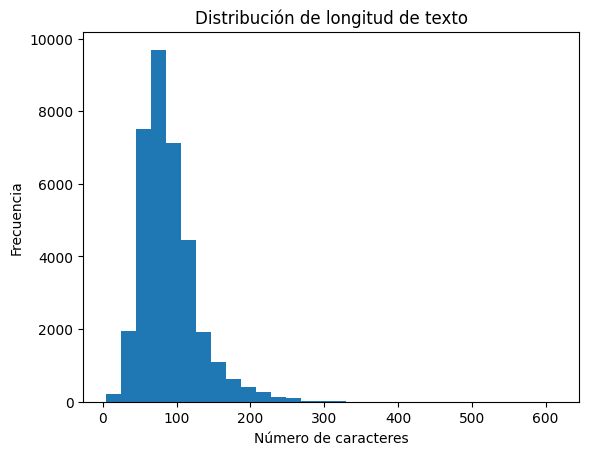

In [ ]:
plt.figure()
df["texto_norm"].str.len().plot(kind="hist", bins=30)
plt.title("Distribución de longitud de texto")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.show()

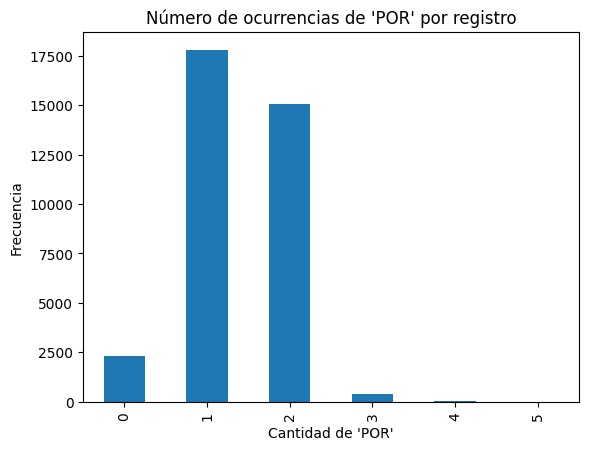

In [ ]:
df["num_por"] = df["texto_norm"].str.count("POR")

plt.figure()
df["num_por"].value_counts().sort_index().plot(kind="bar")
plt.title("Número de ocurrencias de 'POR' por registro")
plt.xlabel("Cantidad de 'POR'")
plt.ylabel("Frecuencia")
plt.show()

#PASO 3 — motor de detección de empaques (envase, forma, volumen)

Objetivo:
 Transformar texto libre en estructura semántica.

 Se identifican 3 niveles principales:
 - Nivel 1: tipo de envase (ej. CAJA, FRASCO)
 - Nivel 2: cantidad de unidades
 - Nivel 3: forma farmacéutica
 - Nivel 4: volumen o concentración

 Esto permite representar el texto como una estructura jerárquica.


##3.1 — Definir las listas globales

In [ ]:

# ================================
# FORMAS FARMACÉUTICAS
# ================================

FORMAS = [
    "TABLETA", "TABLETAS",
    "CAPSULA", "CAPSULAS",
    "COMPRIMIDO", "COMPRIMIDOS",
    "UNIDADES",
    "GRANULADO",
    "POLVO",
    "SUSPENSION",
    "SOLUCION",
    "JARABE",
    "GOTAS",
    "VIAL", "VIALES",
    "AMPOLLA", "AMPOLLAS",
    "AMPOLLETA", "AMPOLLETAS",
    "AMPOULEPACK", "AMPOULEPACKS",
    "AMPOULE-PACK",
    "AMPULA", "AMPULAS",
    "AMPOLA",
    "CARPULA", "CARPULAS", "CARPULES",
    "JERINGA", "JERINGA PRELLENADA", "JERINGAS PRELLENADAS",
    "SOBRE",
    "TUBO",
    "SACHET",
    "INHALADOR", "INHALACIONES",
    "IMPLANTE",
    "LAMINAS",
    "LAPICERA", "LAPICERO",
    "DOSIS",
    "OVULO", "OVULOS",
    "PLUMA", "PLUMAS",
    "GOTERO", "GOTEROS",
    "ENEMA", "ENEMAS",
    "CARTUCHO", "CARTUCHOS",
    "OPTISET", "OPTISETS",
    "PARCHES"
]


##3.2 — Compilar regex de forma farmacéutica

In [ ]:
regex_forma = re.compile(
    r'(\d+)\s*(' + '|'.join(FORMAS) + r')'
)

In [ ]:
regex_forma_sin_num = re.compile(
    r'\b(' + '|'.join(FORMAS) + r')\b'
)

In [ ]:
def extraer_cantidad_forma(texto):

    # Caso 1: número + forma
    match = regex_forma.search(texto)

    if match:
        cantidad = int(match.group(1))
        forma = match.group(2)
        return cantidad, forma

    # Caso 2: forma sin número
    match2 = regex_forma_sin_num.search(texto)

    if match2:
        return 1, match2.group(1)

    return None, None



##3.3 — Función optimizada para cantidad + forma

def extraer_cantidad_forma(texto):

    match = regex_forma.search(texto)

    if match:
        cantidad = int(match.group(1))
        forma = match.group(2)
        return cantidad, forma

    return None, None


##3.4 — Definir envases

In [ ]:
ENVASES = [
    "FRASCO","FRASCOS","FCO",
    "CAJA","CAJAS","CJA","PLEGADIZA",
    "BOLSA","BOLSAS",
    "BOTELLA","BOTELLAS",
    "CARTON",
    "CARTUCHO","CARTUCHOS",
    "CILINDRO","CILINDROS",
    "DISPENSADOR",
    "EMPAQUE",
    "ENVASE",
    "ESTUCHE",
    "TANQUE",
    "ULTRABAG",
    "POTE",
    "TERMO",
    "DEWAR",
    "GARRAFA",
    "PALLET TANK",
    "GALON",
    "KIT",
    "LATA",
    "IMPLANTE",
    "TARRO",
    "INHALADOR"
]


##3.5 — Equivalencias

In [ ]:
ENVASE_EQUIVALENCIAS = {
    "FCO": "FRASCO",
    "FRASCOS": "FRASCO",
    "CAJAS": "CAJA",
    "BOLSAS": "BOLSA",
    "BOTELLAS": "BOTELLA",
    "CARTUCHOS": "CARTUCHO",
    "CILINDROS": "CILINDRO"
}


##3.6 — Compilar regex de envases

In [ ]:
regex_envase_numero = re.compile(
    r'(\d+)\s*(' + '|'.join(ENVASES) + r')'
)


3.7 — Función detectar_envase

 Se prioriza la detección con número (ej. "2 CAJAS"),
 pero también se contempla detección sin cantidad explícita.

 Se aplican equivalencias para reducir variabilidad semántica
 (ej. "FCO" → "FRASCO").

In [ ]:
def detectar_envase(texto):

    match = regex_envase_numero.search(texto)

    if match:

        cantidad = match.group(1)
        envase = match.group(2)

        if envase in ["PLEGADIZA","CJA"]:
            envase = "CAJA"

        envase = ENVASE_EQUIVALENCIAS.get(envase, envase)

        return f"{cantidad} {envase}"


    # detección simple si no hay número

    if "FRASCO" in texto or "FCO" in texto:
        return "FRASCO"

    if "CAJA" in texto or "PLEGADIZA" in texto:
        return "CAJA"

    for env in ENVASES:
        if env in texto:

            env = ENVASE_EQUIVALENCIAS.get(env, env)

            if env in ["PLEGADIZA","CJA"]:
                env = "CAJA"

            return env

    return None


3.8. Detectar volumen

In [ ]:
regex_volumen = re.compile(
    r'(\d+(?:\.\d+)?)\s*(ML|MG|G|UI|%|M3|M 3|L|KG|CC)'
)


3.9. Función de volumen

In [ ]:
def detectar_volumen(texto):

    match = regex_volumen.search(texto)

    if match:
        return match.group(0)

    return None


#PASO 4

##4.2 — Detectar envase

In [ ]:
df["nivel1_envase"] = df["texto_norm"].apply(detectar_envase)

4.3 — Extraer cantidad y forma

In [ ]:
cantidad_forma = df["texto_norm"].apply(extraer_cantidad_forma)


In [ ]:
df[["nivel2_cantidad", "nivel3_forma"]] = pd.DataFrame(
    cantidad_forma.tolist(),
    index=df.index
)


PASO 4.4 — Detectar volumen

In [ ]:
df["nivel4_volumen"] = df["texto_norm"].apply(detectar_volumen)

## PASO 4.5 — Corrección envase vs forma

In [ ]:
mask_inconsistente = (
    df["nivel3_forma"].isin(["VIAL", "AMPOLLA"]) &
    df["nivel1_envase"].notna() &
    df["nivel1_envase"].str.contains("FRASCO", na=False)
)

df.loc[mask_inconsistente, "nivel1_envase"] = None

#5. Validación

Objetivo:
 Validar coherencia entre la cantidad reportada (cantidadcum)
 y la estructura extraída del texto.

 En lugar de usar comparación directa, se evalúan múltiples niveles:
 - Nivel 2: unidades principales
 - Nivel 1: envase
 - Nivel 4: volumen
 - Lista de cantidades ("POR X") para capturar jerarquía

 Además, se introduce lógica de múltiplos,
 ya que los empaques suelen ser estructuras compuestas.

 Ejemplo:
 CAJA POR 10 BLISTER DE 10 TABLETAS → 100 vs 10 (válido como múltiplo)

  Se evita una validación rígida (==) para permitir estructuras jerárquicas,
 lo que reduce falsos positivos en la detección de inconsistencias.



In [ ]:
# ================================
# PASO 5 — VALIDACIÓN ROBUSTA
# ================================

regex_numero_inicio = re.compile(r'^(\d+)')

def extraer_numero(texto):

    if pd.isna(texto):
        return None

    match = regex_numero_inicio.match(str(texto))

    if match:
        return int(match.group(1))

    return None


def validar_cantidad(row):

    try:
        cc_val = row["cantidadcum"]

        if pd.isna(cc_val):
            return None

        cc = int(cc_val)

    except:
        return "NO_COMPARABLE"

    # =========================
    # NIVEL 2 (cantidad principal)
    # =========================
    try:
        n2 = int(row["nivel2_cantidad"]) if not pd.isna(row["nivel2_cantidad"]) else None
    except:
        n2 = None

    if n2 not in [None, 0]:
        if n2 == cc:
            return "OK"
        if cc % n2 == 0 or n2 % cc == 0:
            return "MULTIPLO"

    # =========================
    # NIVEL 1 (envase)
    # =========================
    n1 = extraer_numero(row["nivel1_envase"])

    if n1 not in [None, 0]:
        if n1 == cc:
            return "OK_ENVASE"
        if cc % n1 == 0 or n1 % cc == 0:
            return "MULTIPLO_ENVASE"

    # =========================
    # NIVEL 4 (volumen)
    # =========================
    n4 = extraer_numero(row["nivel4_volumen"])

    if n4 not in [None, 0]:
        if n4 == cc:
            return "OK_VOLUMEN"
        if cc % n4 == 0 or n4 % cc == 0:
            return "MULTIPLO_VOLUMEN"

    # =========================
    # LISTA POR (jerarquía)
    # =========================
    lista = row.get("lista_por", [])

    for val in lista:
        if val == cc:
            return "OK_LISTA"
        if val != 0 and (cc % val == 0 or val % cc == 0):
            return "MULTIPLO_LISTA"

    return "CANTIDAD_DIFERENTE"


# aplicar validación inicial
df["alerta_cantidad"] = df.apply(validar_cantidad, axis=1)

#PASO 6: Corregir con subempaques

Objetivo:
 Identificar estructuras de empaque compuestas (subempaques),
 donde la cantidad total no está explícita directamente.

 Ejemplo:
 "CAJA POR 10 BLISTER DE 10 TABLETAS"
 → subempaque = 10 * 10 = 100

 Se calcula una cantidad derivada (nivel5_subempaque)
 que representa el total real de unidades.


In [ ]:
##PASO 6.1 — Definir tipos de subempaque


In [ ]:
SUBEMPAQUES = [
    "BLISTER",
    "SOBRE",
    "SOBRES",
    "TIRA",
    "TIRAS",
    "STRIP",
    "AMPOLLA",
    "AMPOLLETAS",
    "VIAL",
    "VIALES",
    "TUBO",
    "TUBOS"
]

PASO 6.2 — Regex

In [ ]:
regex_subempaque = re.compile(
    r'(\d+)\s*(' + '|'.join(SUBEMPAQUES) + r')\s*.*?\s*(\d+)\s*'
    r'(TABLETA|TABLETAS|CAPSULA|CAPSULAS|COMPRIMIDO|COMPRIMIDOS|AMPOLLA)',
)


PASO 6.3 — Función calcular_subempaque

In [ ]:
def calcular_subempaque(texto):

    match = regex_subempaque.search(texto)

    if not match:
        return None

    tipo = match.group(2)

    # Regla especial TUBO
    if tipo in ["TUBO", "TUBOS"]:
        if "TABLETA" not in texto and "TABLETAS" not in texto:
            return None

    try:
        subempaque = int(match.group(1))
        unidades = int(match.group(3))
    except:
        return None

    return subempaque * unidades


PASO 6.4 — Crear columna nivel5_subempaque


In [ ]:
df["nivel5_subempaque"] = df["texto_norm"].apply(calcular_subempaque)

def extraer_por_cantidades(texto):
    matches = re.findall(r'POR\s+(\d+)', texto)
    return [int(x) for x in matches] if matches else []

df["lista_por"] = df["texto_norm"].apply(extraer_por_cantidades)


PASO 6.5 — Aplicar corrección automática

In [ ]:
mask_base = (
    (df["alerta_cantidad"] == "CANTIDAD_DIFERENTE") &
    (df["nivel2_cantidad"].notna())
)

# usar subempaque SOLO si mejora
mask_sub = mask_base & df["nivel5_subempaque"].notna()

df.loc[
    mask_sub & (df["nivel5_subempaque"] > df["nivel2_cantidad"]),
    "nivel2_cantidad"
] = df["nivel5_subempaque"]

Se extraen todas las cantidades precedidas por "POR"
 para capturar la jerarquía completa del empaque.

 Esto permite identificar múltiples niveles de agrupación,
 y seleccionar el nivel más representativo (generalmente el mayor).


In [ ]:
def seleccionar_cantidad_correcta(row):

    lista = row["lista_por"]

    if not lista:
        return row["nivel2_cantidad"]

    return max(lista)

In [ ]:
mask_multi = mask_base & df["lista_por"].apply(lambda x: len(x) > 1)

df.loc[mask_multi, "nivel2_cantidad"] = df.loc[mask_multi].apply(
    seleccionar_cantidad_correcta, axis=1
)

PASO 6.6 — Revalidar contra cantidadcum

 Se separa la lógica de validación (estado_validacion)
 de la alerta operativa (alerta_cantidad).

 Esto permite:
 - Mantener trazabilidad del proceso
 - Analizar resultados intermedios
 - Facilitar integración con modelos de IA


In [ ]:
df["estado_validacion"] = df.apply(validar_cantidad, axis=1)

In [ ]:
df["alerta_cantidad"] = df["estado_validacion"].apply(
    lambda x: "CANTIDAD_DIFERENTE" if x == "CANTIDAD_DIFERENTE" else None
)

#PASO 7: Limpieza final
Se eliminan registros irrelevantes o administrativos
 que no aportan al análisis (ej. exportaciones, pendientes).

 Esto mejora la calidad del dataset para análisis y modelado.


In [ ]:
PATRONES_ELIMINAR = [
    "EXPORTAR",
    "EXPORTACION",
    "PENDIENTE",
    "M.MEDICA"
]


PASO 7.2 — Crear regex única

In [ ]:
regex_eliminar = re.compile("|".join(PATRONES_ELIMINAR), re.IGNORECASE)

PASO 7.3 — Filtrar el DataFrame

In [ ]:
mask_eliminar = df["Unidad de empaque"].str.contains(regex_eliminar, na=False)

filas_eliminadas = mask_eliminar.sum()

df = df.loc[~mask_eliminar].copy()


PASO 7.4 — Reportar limpieza


In [ ]:
print("Filas eliminadas:", filas_eliminadas)
print("Dimensiones después de limpieza:", df.shape)

display(df.head())

Filas eliminadas: 134
Dimensiones después de limpieza: (35455, 26)


,expediente,CUM,Concentración DCI,Principio activo,Principio activo ATC,Denominación marcaria,Cantidad,Unidad de medida,Forma farmacéutica,Vía de administración,...,combo,num_por,nivel1_envase,nivel2_cantidad,nivel3_forma,nivel4_volumen,alerta_cantidad,nivel5_subempaque,lista_por,estado_validacion
0,20064694,20064694-01,ABACAVIR 300mg,ABACAVIR SULFATO EQUIVALENTE A ABACAVIR,ABACAVIR,ABACAR®,300.0,mg,TABLETA RECUBIERTA,ORAL,...,60.0 CADA TABLETA,1,FRASCO,60.0,TABLETA,None,None,NaN,[60],OK
1,20065664,20065664-02,ABACAVIR SULFATO 20mg/1ml,ABACAVIR SULFAT0 2.34 G EQUIVALENTE A ABACAVIR,ABACAVIR,ABACAR® SOLUCION ORAL,2.0,g,SOLUCION ORAL,ORAL,...,1.0 100 ML DE SOLUCION ORAL,0,FRASCO,1.0,SOLUCION,240 ML,None,NaN,[],OK
2,20041743,20041743-01,ABATACEPT 125mg/1ml,ABATACEPT,ABATACEPT,ORENCIA® SOLUCION INYECTABLE PARA ADMINISTRACI...,125.0,mg,SOLUCION INYECTABLE,SUBCUTANEA,...,4.0 JERINGA PRELLENADA,0,CAJA,4.0,JERINGA,None,None,NaN,[],OK
3,20148436,20148436-03,ABIRATERONA ACETATO 250mg,ABIRATERONA ACETATO,ABIRATERONA,ABIRAND ® 250 MG TABLETAS,250.0,mg,TABLETA,ORAL,...,120.0 TABLETAS,2,FRASCO,120.0,UNIDADES,None,None,NaN,[120],OK
4,20178599,20178599-01,ABIRATERONA ACETATO 500mg,ACETATO DE ABIRATERONA,ABIRATERONA,ABIRAPROST®,500.0,mg,TABLETA,ORAL,...,60.0 TABLETA,0,1 FRASCO,60.0,TABLETA,150 ML,None,NaN,[],OK


PASO 7.5 — Crear subconjunto con inconsistencias

In [ ]:
df_inconsistencias = df[df["alerta_cantidad"] == "CANTIDAD_DIFERENTE"].copy()

print("Número de inconsistencias detectadas:", df_inconsistencias.shape[0])

Número de inconsistencias detectadas: 177


In [ ]:
print(f"Número de valores N/A en 'alerta_cantidad': {df['alerta_cantidad'].isna().sum()}")

Número de valores N/A en 'alerta_cantidad': 35278


PASO 7.6 — Análisis de inconsistencia

In [ ]:
print("\nCantidades más frecuentes con inconsistencia:")

display(
    df_inconsistencias["cantidadcum"]
    .value_counts()
    .head(10)
)



Cantidades más frecuentes con inconsistencia:


,count
cantidadcum,
1.0,37
30.0,9
10.0,8
2.0,7
14.0,6
6.0,6
3.0,5
4.0,5
200.0,5


In [ ]:
print("\nUnidades de referencia más frecuentes con inconsistencia:")

display(
    df_inconsistencias["unidadreferencia"]
    .value_counts()
    .head(10)
)



Unidades de referencia más frecuentes con inconsistencia:


,count
unidadreferencia,
TABLETA RECUBIERTA,24
VIAL,19
100 ML.,18
CILINDRO DE COLOR BLANCO Y NEGRO,6
CADA TABLETA CONTIENE,6
CILINDRO METALICO CONTIENE OXIGENO,6
M3,5
CILINDRO OXIGENO,5
CADA ML CONTIENE 2X10^13 GENOMAS VECTORIALES (VG),5


In [ ]:
df["estado_validacion"].value_counts()

,count
estado_validacion,
OK,27789
MULTIPLO,3646
MULTIPLO_VOLUMEN,1441
OK_VOLUMEN,1296
OK_ENVASE,514
OK_LISTA,254
MULTIPLO_ENVASE,224
CANTIDAD_DIFERENTE,177
MULTIPLO_LISTA,114


In [ ]:
output_filename = "Ambulatorios_conreglas.xlsx"

df.to_excel(output_filename, index=False)

files.download(output_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#8. Entrenamiento del modelo de aprendizaje automático

 Objetivo:
 Complementar el sistema basado en reglas con un modelo de IA
 capaz de manejar casos ambiguos o no cubiertos por reglas.

 Enfoque:
 Sistema híbrido:
 - Reglas determinísticas → mayoría de casos
 - Modelo supervisado → casos complejos o ambiguos


##8.1. Creación del target

 Se construye una variable objetivo a partir de la validación:

 - CORRECTO: consistencia directa
 - CORREGIBLE: inconsistencia estructural (múltiplos)
 - ERROR_REAL: inconsistencia no explicable


In [ ]:
def crear_target(row):

    if row["estado_validacion"] in [
        "OK", "OK_ENVASE", "OK_VOLUMEN", "OK_LISTA"
    ]:
        return "CORRECTO"

    if row["estado_validacion"] in [
        "MULTIPLO", "MULTIPLO_ENVASE",
        "MULTIPLO_VOLUMEN", "MULTIPLO_LISTA"
    ]:
        return "CORREGIBLE"

    return "ERROR_REAL"


df["target_ia"] = df.apply(crear_target, axis=1)

In [ ]:
# MODELO 1 (binario)
df["target_binario"] = df["target_ia"].apply(
    lambda x: "CORRECTO" if x == "CORRECTO" else "NO_CORRECTO"
)

# MODELO 2 (solo casos problemáticos)
df_no_correcto = df[df["target_ia"] != "CORRECTO"].copy()

df_no_correcto["target_fino"] = df_no_correcto["target_ia"].apply(
    lambda x: "CORREGIBLE" if "CORREGIBLE" in x else "ERROR_REAL"
)


df["target_fino"] = df["target_ia"].apply(
    lambda x: "CORREGIBLE" if x == "CORREGIBLE" else "ERROR_REAL"
)

##8.2. Seleccionar features
 Se evita el uso de variables derivadas directamente de las reglas
 (ej. nivel2_cantidad, cantidadcum) para prevenir data leakage.

 En su lugar, se utilizan:
 - Representación textual (TF-IDF)
 - Características simples (longitud, número de "POR")

 Esto permite que el modelo aprenda patrones semánticos reales


In [ ]:
df["num_por"] = df["lista_por"].apply(len)

df["longitud_texto"] = df["texto_norm"].str.len()

3. Texto a vector

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=500)

X_text = vectorizer.fit_transform(df["texto_norm"])

4. Combinar todo

In [ ]:
import numpy as np

X_extra = df[["num_por", "longitud_texto"]].fillna(0)

X = np.hstack([X_text.toarray(), X_extra.values])

#1 MODELO: BINARIO

 Clasificación binaria para detectar registros problemáticos.

 Función:
 Filtrar casos que requieren análisis más profundo.


Split

In [ ]:
from sklearn.model_selection import train_test_split

y_bin = df["target_binario"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

Modelo

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_bin = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced",
    random_state=42
)

model_bin.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=150,
                       random_state=42)

Evaluación

In [ ]:
from sklearn.metrics import classification_report

y_pred = model_bin.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    CORRECTO       0.94      0.97      0.95      5971
 NO_CORRECTO       0.80      0.68      0.73      1120

    accuracy                           0.92      7091
   macro avg       0.87      0.82      0.84      7091
weighted avg       0.92      0.92      0.92      7091



#2 MODELO: CORREGIBLE vs ERROR_REAL

Clasificación específica de casos problemáticos:
 - CORREGIBLE
 - ERROR_REAL

 Este modelo enfrenta un problema de desbalance de clases,
 ya que los errores reales son poco frecuentes.


In [ ]:
df_nc = df[df["target_binario"] == "NO_CORRECTO"].copy()

X_text_nc = vectorizer.transform(df_nc["texto_norm"])

X_extra_nc = df_nc[["num_por", "longitud_texto"]].fillna(0)

X_nc = np.hstack([X_text_nc.toarray(), X_extra_nc.values])

y_nc = df_nc["target_fino"]

Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_nc, y_nc, test_size=0.2, random_state=42, stratify=y_nc
)

Modelo

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_fino = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced",
    random_state=42
)

model_fino.fit(X_train_nc, y_train_nc)

RandomForestClassifier(class_weight='balanced', n_estimators=150,
                       random_state=42)

Evaluación

In [ ]:
from sklearn.metrics import classification_report

y_pred_nc = model_fino.predict(X_test_nc)

print(classification_report(y_test_nc, y_pred_nc))

              precision    recall  f1-score   support

  CORREGIBLE       0.98      0.99      0.99      1086
  ERROR_REAL       0.60      0.43      0.50        35

    accuracy                           0.97      1121
   macro avg       0.79      0.71      0.74      1121
weighted avg       0.97      0.97      0.97      1121



#Integración final

 Sistema final:
 1. Modelo binario detecta si hay problema
 2. Modelo fino clasifica el tipo de problema

 Esto reduce la complejidad del modelo
 y mejora la interpretabilidad del sistema.


In [ ]:
def clasificacion_final(texto, num_por, longitud_texto):

    # vectorizar
    X_text = vectorizer.transform([texto])
    X_extra = np.array([[num_por, longitud_texto]])

    X_input = np.hstack([X_text.toarray(), X_extra])

    # modelo 1
    pred_bin = model_bin.predict(X_input)[0]

    if pred_bin == "CORRECTO":
        return "CORRECTO"

    # modelo 2
    pred_fino = model_fino.predict(X_input)[0]

    return pred_fino

#9. Conclusión
 Se desarrolló un sistema híbrido que combina:
 - Reglas basadas en conocimiento del dominio
 - Modelos de aprendizaje automático

 Este enfoque permite:
 - Alta precisión en casos estructurados
 - Flexibilidad en casos ambiguos
 - Reducción significativa de errores manuales

 El sistema es escalable y adaptable a nuevos patrones
